<a href="https://colab.research.google.com/github/Tikquuss/grokking_algorithmic/blob/main/algorithmic_dataset_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is the code to reproduce the grokking phenomenon of the algorithmic data with MLP from the ICML2025 paper *Grokking Beyond the Euclidean Norm of Model Parameters* (Notsawo et al., 2025), https://arxiv.org/abs/2506.05718, figures 1, 2 and 30. For all the figures of the paper, refer to the official GitHub repository https://github.com/Tikquuss/grokking_beyong_l2_norm

In [1]:
!git clone https://github.com/Tikquuss/grokking_algorithmic
%cd grokking_algorithmic
# ! pip install -r requirements.txt
LOG_DIR="/content/LOGS"

Cloning into 'grokking_algorithmic'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 11 (delta 0), reused 11 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 18.68 KiB | 2.08 MiB/s, done.
/content/grokking_algorithmic


In [3]:
# # local runtune
# %cd D:/DATA/grokking_algorithmic
# LOG_DIR="E:/LOGS/grokking_algorithmic"

D:\DATA\MILA\UdeM\Cours\Grokking\grokking_algorithmic


In [2]:
import os
os.makedirs(LOG_DIR, exist_ok=True)

In [3]:
import torch

from data import get_arithmetic_data
from model import Encoder_Decoder
from trainer import run_experiments, train_m_models, eval_model_classification, get_loss
from checkpointing import get_all_checkpoints, get_all_checkpoints_per_trials
from plotters import plot_loss_accs, FIGSIZE, LINEWIDTH, FONTSIZE

 Define the arguments for the experiment (see the run_experiments function for more details on the arguments)

In [5]:
args = {}

The checkpoints & statistics will be saved in `checkpoint_path={exp_dir}/{exp_name}`,  with `exp_name = get_exp_name_function(args)` (see below).

* The checkpoints will be named `{file_name}_state_{step}_acc={acc}_loss={loss}.pth`
* The statistics will be named `{file_name}.pth`

The function `get_all_checkpoints` can be used to load the checkpoints and statistics from a given exp_dir and exp_name, and the function `plot_loss_accs` can be used to plot the loss and accuracy curves from the statistics.


In [6]:
args['file_name'] = "mlp_algorithmic_dataset"
args['exp_dir'] = f"{LOG_DIR}/{args['file_name']}"
os.makedirs(args['exp_dir'], exist_ok=True)

Set the device to `cuda` if available, otherwise use `cpu`

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
args["device"] = device
print(f'using device: {device}')

using device: cuda


# Data

In [136]:
# Each data point is of the form (a, b, c) where a and b are integers in [0, p) and c = (a <operator> b) mod q
p, q = 97, 97
# p, q = 31, 31
operator = "+" # "+", "-", "*"
# The training set will consist of r_train% of the data, and the test set will consist of the remaining (1 - r_train)% of the data
r_train=0.4
# Batch size for training datatloaders: set to p**2 for full batch training, or a smaller value for mini-batch training.
batch_size=2**11
# Batch size for evaluation datatloaders (we can use a larger batch size for evaluation since we don't need to compute gradients)
eval_batch_size=2**13
# Random seed for reproducibility
seed = 42

# Save the arguments in the args dictionary, which will used by other functions in the codebase (e.g. get_experiment_name, get_model, etc.)
args['p'] = p
args['q'] = q
args['operator'] = operator
args['r_train'] = r_train

In [137]:
(train_loader, train_loader_for_eval, test_loader), (X_train, X_test, y_train, y_test) = get_arithmetic_data(
    p=p,
    q=q,
    operator=operator,
    r_train=r_train,
    batch_size=batch_size,
    eval_batch_size=eval_batch_size
)

args['train_loader'], args['train_loader_for_eval'], args['test_loader'] = train_loader, train_loader_for_eval, test_loader

Data size : train = 3763, test = 5646
Loader size : train = 2, train for val = 1, test = 1


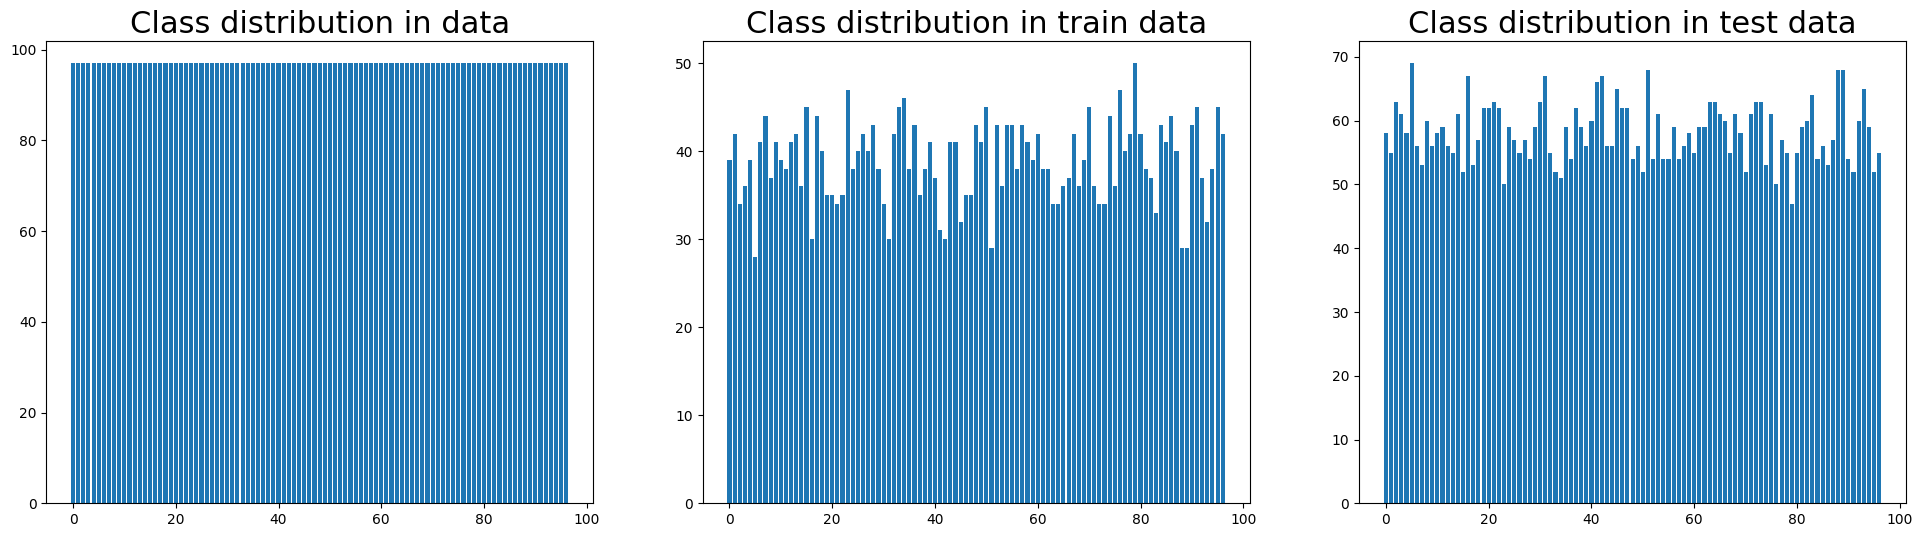

In [138]:
import matplotlib.pyplot as plt

rows, cols = 1, 3
figsize=(6, 4)
figsize=(8, 6)
# figsize=(15, 10)
figsize=(cols*figsize[0], rows*figsize[1])
fig = plt.figure(figsize=figsize)

ax = fig.add_subplot(rows, cols, 1)
ax.bar(range(p), [(y_train==k).sum() + (y_test==k).sum() for k in range(p)])
ax.set_title(f'Class distribution in data', fontsize=22)

ax = fig.add_subplot(rows, cols, 2)
y_train = train_loader_for_eval.dataset.tensors[1].cpu().numpy() # (N,)
ax.bar(range(p), [(y_train==k).sum() for k in range(p)])
ax.set_title(f'Class distribution in train data', fontsize=22)

ax = fig.add_subplot(rows, cols, 3)
y_test = test_loader.dataset.tensors[1].cpu().numpy() # (N,)
ax.bar(range(p), [(y_test==k).sum() for k in range(p)])
ax.set_title(f'Class distribution in test data', fontsize=22)

plt.show()

# Model

The model receives as input a pair of vectors $(a, b) \in \mathbb{R}^{2 \times p}$,  and produces as output a distribution over the possible results of the operation (logit of size $q$).

Typically, the input vectors represent the two operands of an arithmetic operation, where each operand is represented as a one-hot encoded vector of size $p$. The input is thus a tensor of shape `(batch_size, 2, p)`, one-hot encoded, and produces as output a distribution over the possible results of the operation.

The encoder consists of two separate MLPs (one for each input token) that produce representations of the input tokens : $h_1 = \text{encoder}_1(a)$ and $h_2 = \text{encoder}_2(a)$ in $\mathbb{R}^{d}$ each.

The two representations are then aggregated to produce a single representation $h \in \mathbb{R}^{rep\_dim}$
- If aggregation_mode is `sum`, the representations of the two tokens are summed element-wise : $h = h_1 + h_2 \in \mathbb{R}^{d}$.
- If aggregation_mode is `concat`, the representations of the two tokens are concatenated : $h = h_1 \oplus h_2 \in \mathbb{R}^{2d}$.
- If aggregation_mode is `matrix_product`, the representations of the two tokens are multiplied as matrices (with the constraint that $d$ must be a perfect square): $h = \text{vec} \ (\text{vec}^{-1}(h_1) \ \text{vec}^{-1}(h_2)) \in \mathbb{R}^{d}$, with $\text{vec} :  \mathbb{R}^{\sqrt{d} \times \sqrt{d}} \to \mathbb{R}^{d}$ and $\text{vec}^{-1} : \mathbb{R}^{d} \to \mathbb{R}^{\sqrt{d} \times \sqrt{d}}$.
- If aggregation_mode is `hadamard_product`, the representations of the two tokens are multiplied element-wise: $h = h_1 \odot h_2 \in \mathbb{R}^{d}$

In [139]:
args['aggregation_mode'] = 'matrix_product' #  'sum', 'concat', 'matrix_product', 'hadamard_product'
# The dimension of the representations produced by the encoder MLPs (d in the description above)
args['embedding_dim'] = 2**6
# number of hidden layer for the mlp (0 for linear model, ...)
args['num_hidden_layers_mlp'] = 1
# The embedding dimension is multiplied (and rounded) by this number to have the hidden dimension of the decoder MLP
args['width_multiplier_mlp'] = 1.0
# Multiply the parameters of the model by {init_scale} after initialization,
# e.g. to have have larger initial parameters which can delay grokking: Grokking Beyond Algorithmic Data (Liu et al., 2023).
args['init_scale'] = 1.0
# If {init_scale} is too large, it can lead to divergence. Initializing the classifier to zero
# can help mitigate this issue : Dichotomy of Early and Late Phase Implicit Biases Can Provably Induce Grokking (Lyu et al., 2024).
args['last_layer_zero_init'] = False

In [140]:
def get_model(args):
    # The encoder is just an embedding layer that maps the one-hot encoded input of size p to a dense representation of size embedding_dim
    # A deeper MLP can be used, but we use a simple embedding layer for simplicity since it achieves good performance on this task.
    widths_encoder = [args['q'], args['embedding_dim']] # embedding layer
    # widths of each hidden layer of the decoder MLP, with the last layer having width q (number of classes)
    widths_decoder = [args['embedding_dim']] + [int(args['embedding_dim']*args['width_multiplier_mlp'])]*args['num_hidden_layers_mlp'] + [args['q']]
    model = Encoder_Decoder(
            args['aggregation_mode'],
            widths_encoder,
            widths_decoder,
            # We don't use any activation function for the encoder since it's just an embedding layer,
            # but other activations can be used as well (e.g. ReLU, Tanh, GELU, etc.)
            activation_class_encoder=None,
            # We use ReLU activations for the decoder MLP, but other activations can be used as well (e.g. Tanh, GELU, etc.)
            activation_class_decoder=torch.nn.ReLU,
            # bias terms for the encoder, decoder and classifier
            bias_encoder=False,
            bias_decoder=False,
            bias_classifier=False,
            # This is dropout on top of the encoder, and before the classifier
            dropout=0.0,
            # Initialize the parameters of the model using a {type_init} distribution : 'kaiming', 'xavier', 'normal'
            init_params=True,
            type_init='normal',
            # Multiply the parameters of the model by {init_scale} after initialization
            init_scale=args['init_scale'],
            # Wheather to initialize the classifier to zero, which can help mitigate divergence issues when using a large {init_scale}.
            last_layer_zero_init=args['last_layer_zero_init'],
            # Seed for reproducibility of the model initialization,
            # but the seed is also set globally at the beginning of the experiment, so setting it here is not necessary.
            seed=None,
    )
    return model


args['model'] = get_model(args)
print("Model :", args['model'], "\n")
n_params = sum(p.numel() for p in args['model'].parameters() if p.requires_grad)
print(f"Number of model trainable parameters : {n_params}")

Model : Encoder_Decoder(
  (encoder): ModuleList(
    (0-1): 2 x Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=97, out_features=64, bias=False)
    )
  )
  (readout): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=False)
    (1): ReLU()
  )
  (fc): Linear(in_features=64, out_features=97, bias=False)
) 

Number of model trainable parameters : 22720


In [141]:
# Test the model on a batch of data to check that the forward pass works and produces outputs of the expected shape
with torch.no_grad():
    for x, y in train_loader:
        logits, h = args['model'](x, activation=True)
        loss = torch.nn.functional.cross_entropy(logits, y)
        print("x.shape, y.shape, h.shape, logits.shape", x.shape, y.shape, h.shape, logits.shape)
        print(f"Loss: {loss.item()}")
        break

x.shape, y.shape, h.shape, logits.shape torch.Size([2048, 2, 97]) torch.Size([2048]) torch.Size([2048, 64]) torch.Size([2048, 97])
Loss: 4.574693202972412


# Experiments

* The functions `get_loss` and `eval_model` (from trainer.py) are used to compute the loss and evaluate  the model during training and evaluation of the experiment. These functions can be customized to implement different training and evaluation procedures as soon as they receive the right arguments and produce the expected outputs (see trainer.py for details).

* The function `get_other_metrics` can be used to compute other metrics besides the loss and accuracy during  training and evaluation of the experiment, e.g. the $\ell_2$ norm of the weights and gradients, the sharpness of the loss landscape, etc. This function receives as input the model, the input batch `X`, the labels `Y`, the model outputs `Y_hat`, and the `loss`. Backward has already been called to compute the gradients (and they are still available in the model parameters), so the gradients of the model parameters are available and can be used to compute metrics related to the gradients.

  If `get_other_metrics` is set to `None` (or not provide in args), no other metrics besides the loss and accuracy will be computed during training and evaluation.

In [168]:
args['get_loss'] = get_loss
args["eval_model"] = eval_model_classification
args['get_other_metrics']=None

def get_other_metrics(model, X, Y, Y_hat, loss):
    metrics = {}
    with torch.no_grad():
        # only weight
        #W = torch.cat([p.data.detach().cpu().flatten() for name, p in model.named_parameters() if 'weight' in name])
        # weight and bias
        W = torch.cat([p.data.detach().cpu().flatten() for p in model.parameters() ])
        metrics["l2_norm"] = torch.norm(W.flatten(), p=2)

        G = torch.cat([p.grad.detach().cpu().flatten() for p in model.parameters() if p.grad is not None])
        metrics['grad_norm'] = torch.norm(G.flatten(), p=2)

    return metrics

args['get_other_metrics'] = get_other_metrics

Populate the args dictionary with
- the `optimizer`: we use AdamW, but other optimizers and hyperparameters can be used as well.
- the `criterion`: we use CrossEntropyLoss, but other (classification) loss functions can be used as well.
- the `get_exp_name_function` function : the checkpoints and statistics are saved in `checkpoint_path={exp_dir}/{exp_name}`,  with `exp_name = get_exp_name_function(args)`.

In [169]:
learning_rate = 5e-3
weight_decay = 1e-6

args['model'] = get_model(args)
args["optimizer"] = torch.optim.Adam(args['model'].parameters(), lr=learning_rate, weight_decay=weight_decay)
args["criterion"] = torch.nn.CrossEntropyLoss()

args["get_exp_name_function"] = lambda args : f"id={args['exp_id']}-p={args['p']}-q={args['q']}-operator={args['operator']}-rtrain={args['r_train']}"

# Test the {get_exp_name_function} to check that it produces the expected experiment name from the arguments
args['exp_id'] = 'my_id'
print(args["get_exp_name_function"](args))

id=my_id-p=97-q=97-operator=+-rtrain=0.4


You can use the following to try different regularization like in *Grokking Beyond the Euclidean Norm of Model Parameters* (Notsawo et al., 2025).
In that case, make sure `weight_decay=0` in `optimizer`: the following directly add the regularizer to the training error before performing the gradient update

In [170]:
# args['beta_dic'] = {2 : 1e-6} # l2 regularization : promote low values of the params
# args['beta_dic'] = {1 : 1e-6} # l1 regularization : promote sparsity
# args['beta_dic'] = {"nuc" : 1e-6} # nuclear norm regularization : promote low rankness
# def get_get_loss(beta_dic):
#     def get_loss_func(model, batch_x, batch_y, criterion) :
#         loss, scores = get_loss(model, batch_x, batch_y, criterion)
#         p, beta_p = next(iter(beta_dic.items()))
#         if beta_p!=0:
#             # Add beta_p * norm(params) to the loss function
#             for name, param in model.named_parameters():
#                 # Target weight tensors only
#                 if 'weight' in name and param.requires_grad:
#                     loss = loss + beta_p * torch.norm(param, p=p)
#         return loss, scores
#     return get_loss_func
# args['get_loss'] = get_get_loss(beta_dic=args['beta_dic'])


Let $N$ be the number of training samples (`N = len(X_train)`) and $B$ be the batch size (`B=batch_size`). The number of batches is $L = \lfloor \frac{N}{B} \rfloor + \mathbb{1}(N \% B \ne 0) = \lfloor \frac{N+B-1}{B} \rfloor$, that is `n_batchs = len(train_loader)`.

Giving the number of training steps $S$, the number of epochs is $E = \lfloor \frac{S}{L} \rfloor + \mathbb{1}(S \% L \ne 0) = \lfloor \frac{S+L-1}{L} \rfloor$ : `(n_steps + n_batchs - 1) // n_batchs`


In [171]:
args.update({
    # Number of training steps
    "n_steps" : 10**4+1,
    # Evaluate the model every {eval_period} steps, and also for the first {eval_first} steps:
    # 0, 1, ..., {eval_first}, {eval_first} + {eval_period}, {eval_first} + 2*{eval_period}, ..., {n_steps}
    "eval_first": 10**1,
    "eval_period": 10**1,
    # Print the training loss and metrics every {print_step} steps during training.
    "print_step": 10**2,
    # Save the model checkpoint every {save_model_step} steps during training, and also at the end of training: {file_name}_state_{step}_acc={acc}_loss={loss}.pth
    "save_model_step":10**3,
    # Save the training statistics every {save_statistic_step} steps during training, and also at the end of training: {file_name}.pth
    "save_statistic_step":10**3 * 1
})

Experiment id `exp_id` to save the checkpoints and statistics (see `get_exp_name_function`)
* if `None`, it is set to `id+1`, with `id` being the maximum id of the existing checkpoints in the `exp_dir`, so that a new experiment is created without overwriting the existing ones.
* If not `None`, the provided id will be used in the experiment name even if an experiment with the same id already exists in the `exp_dir`, so be careful when setting this argument to not overwrite existing experiments.

In [172]:
args['exp_id'] = None

# Set the random seed for reproducibility (this seed is used for the model initialization and any other random operations)
# Set to None to not set the random seed and have different results at each run.
args['seed'] = None

# Whether to print the metrics during training or not.
args["verbose"] = True

`run_experiments(args)` returns:
* `args`: current `args` + some modifications, like `args['checkpoint_path'] = {exp_dir}/{exp_name}`, etc.
* `model`: the trained model at the end of training of the experiment.
* `metrics`: a dictionary containing the training and evaluation metrics computed during training and evaluation of the experiment
    - `all_steps`: list of step numbers at which the metrics were computed during training.
            that is `0, 1, ..., eval_first, eval_first + eval_period, eval_first + 2*eval_period, ..., n_steps`
    - `steps_epoch`: dictionary `{step: epoch}` to map the step numbers to epoch numbers, since the metrics are computed every `eval_period` steps and not every epoch.
    - `train`: dictionary `{metric: [list of values]}` with values returned by `eval_model` on the `train_loader_for_eval` at each `all_steps`.
           The default `eval_model` returns the `loss` and `accuracy`, but other metrics can be computed as well by customizing the `eval_model` function.
    - `test`: dictionary `{metric: [list of values]}` with values returned by `eval_model` on the `test_loader` at each `all_steps`.
    - other metrics computed by `get_other_metrics` (if not None) during training are also computed each `all_steps` and included in `metrics['metric_name']`
    
      For example, if `get_other_metrics` returns a dictionary with keys `l2_norm` and `grad_norm`, then `metrics['l2_norm']` and `metrics['grad_norm']` will contain the list of values of these metrics computed at each `all_steps`.

In [173]:
args["n_steps"] = 2*10**4+1

args, model, all_metrics = run_experiments(args)
#args, all_models_per_trials, all_metrics = train_m_models(args, M=2, seeds=[0,1]) # see trainer.py

file_name : mlp_algorithmic_dataset_alpha=0.1
exp_dir : /content/LOGS/mlp_algorithmic_dataset_alpha=0.1
device : cuda
p : 97
q : 97
operator : +
r_train : 0.4
aggregation_mode : matrix_product
embedding_dim : 64
num_hidden_layers_mlp : 1
width_multiplier_mlp : 1.0
init_scale : 1.0
last_layer_zero_init : False
optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.005
    maximize: False
    weight_decay: 1e-06
)
criterion : CrossEntropyLoss()
exp_id : 11
n_steps : 20001
eval_first : 10
eval_period : 10
print_step : 100
save_model_step : 1000
save_statistic_step : 1000
seed : None
verbose : True
checkpoint_path : /content/LOGS/mlp_algorithmic_dataset_alpha=0.1/id=11-p=97-q=97-operator=+-rtrain=0.4
beta_dic : {1: 0.0, 2: 1e-06, 'nuc': 0.0}
Model : Encoder_Decoder(
  (encoder): ModuleList(
    (0-1): 2 x Sequential(
      (0)

Training (epochs)...:   0%|          | 0/10001 [00:00<?, ?it/s]


Step 1/20002 | Train loss : 4.573775 | Train accuracy : 0.017805 | Test loss : 4.574830 | Test accuracy : 0.009210 | l2_norm: 13.130009 | grad_norm: 0.003387


Training (epochs)...:   1%|          | 52/10001 [00:03<08:16, 20.02it/s]


Step 100/20002 | Train loss : 1.042120 | Train accuracy : 0.773851 | Test loss : 9.069233 | Test accuracy : 0.007439 | l2_norm: 60.615437 | grad_norm: 0.201918


...


Step 19900/20002 | Train loss : 0.000040 | Train accuracy : 1.000000 | Test loss : 0.000051 | Test accuracy : 1.000000 | l2_norm: 45.517570 | grad_norm: 0.000047


Training (epochs)...: 100%|█████████▉| 9999/10001 [09:51<00:00, 22.34it/s]


Step 20000/20002 | Train loss : 0.000040 | Train accuracy : 1.000000 | Test loss : 0.000051 | Test accuracy : 1.000000 | l2_norm: 45.518837 | grad_norm: 0.000047


Training (epochs)...: 100%|██████████| 10001/10001 [09:51<00:00, 16.90it/s]


Step 20002/20002 | Train loss : 0.000040 | Train accuracy : 1.000000 | Test loss : 0.000051 | Test accuracy : 1.000000 | l2_norm: 45.519199 | grad_norm: 0.000048


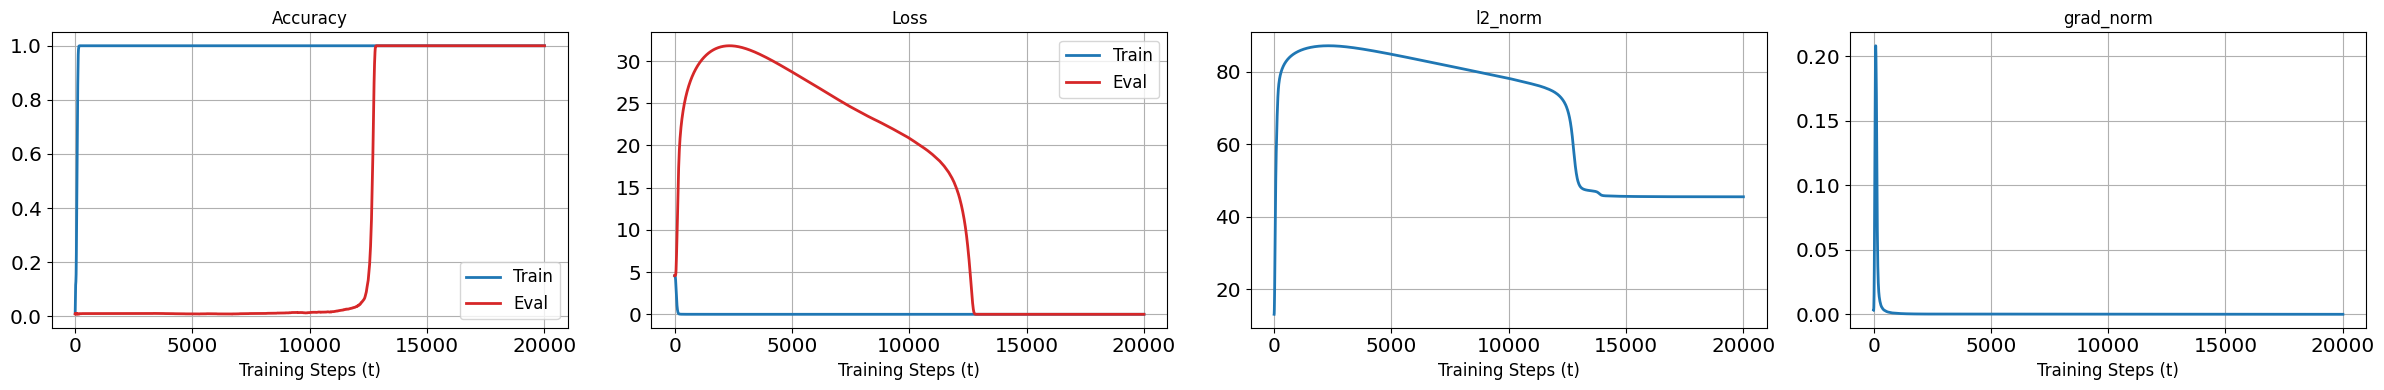

In [174]:
plot_loss_accs(
    all_metrics,
    # They should be keys in all_metrics
    train_test_metrics_names = ["accuracy", "loss"],
    other_metrics_names = ["l2_norm", "grad_norm"],
    # mutiple_runs is used to plot the mean and std of the metrics across multiple runs: train_m_models
    multiple_runs=False,
    # Put the x-axis and y-axis in log scale or not.
    log_x=False, log_y=False,
    figsize=FIGSIZE, linewidth=LINEWIDTH, fontsize=FONTSIZE,
    # If file_name and file_path are provided, the plot will be saved as {file_path}/{file_name}.pdf, otherwise the plot will not be saved.
    file_name=None, file_path=None,
    # Whether to show the plot or not. Set it to False to save the plot without showing it.
    show=True
)

**Load the checkpoints**

* If `just_files=False`, the model will return a dictionnary `{step: state}` with `state = {'model_state_dict': model state dict, 'optimizer_state_dict': optimizer state dict}`.
* Otherwise, a dictionnary `{step: file path}` will be returned, and the user will need to do `torch.load` with each file path to get the `state`.

In [186]:
just_files=True
all_models, all_metrics = get_all_checkpoints(checkpoint_path=args['checkpoint_path'], file_name=args['file_name'], just_files=just_files)

# checkpoints and statistics are from multiple runs (train_m_models)
#all_models_per_trials, all_statistics_dic = get_all_checkpoints_per_trials(all_checkpoint_paths=args['all_checkpoint_paths'], file_name=args['file_name'], just_files=just_files)

In [187]:
from tqdm import tqdm
for step in tqdm(all_models.keys(), total=len(all_models)):
    if just_files :
        file_path = all_models[step]
        state = torch.load(file_path)
    else :
        state = all_models[step]

    model = get_model(args)
    model.load_state_dict(state['model_state_dict'])

    # DO STUFFS WITH THE model

100%|██████████| 33/33 [00:00<00:00, 199.79it/s]


# Scaling the grokking delay

Increasing the learning rate and/or the $\ell_2$ regularization strength accelerates grokking, as shown in *Grokking Beyond the Euclidean Norm of Model Parameters (Notsawo et al., 2025)*. Here we reproduce figures 1, 2, and 30 from that paper for $\ell_2$ regularization (the paper results go beyond this specific regularization).

Note that other factors can influence the grokking delay, like a larger initialization scale `init_scale` and a small weight decay: *Grokking Beyond Algorithmic Data (Liu et al., 2023).*

So you can also play with `init_scale` to change the grokking delay. But be aware that if the initialization scale is too small or too large, there won’t be any learning at all.  If `init_scale` is too large, initializing the classifier to zero (`last_layer_zero_init = True`) can help mitigate this divergence issue: *Dichotomy of Early and Late Phase Implicit Biases Can Provably Induce Grokking (Lyu et al., 2024)*.

In [191]:
# Weigth decays
all_beta = [1e-7, 5e-7, 1e-6, 5e-6, 1e-5, 5e-5]

# Learning rates
all_alpha = [1e-3, 1e-2, 1e-1]

# I set a small number of steps to test the code: use a larger value Ω(2 x 10^4) for real experiment
args["n_steps"] = 3*10**1 + 1
args["verbose"] = False
args['seed'] = 42

**Train**

In [192]:
for i, alpha in enumerate(all_alpha):

    args['file_name'] = f"mlp_algorithmic_dataset_alpha={alpha}"
    args['exp_dir'] = f"{LOG_DIR}/{args['file_name']}"
    os.makedirs(args['exp_dir'], exist_ok=True)

    for j, beta in enumerate(all_beta) :
        print(f"alpha = {alpha}, {(i+1)}/{len(all_alpha)}, beta={beta}, {(j+1)}/{len(all_beta)}")

        args['exp_id'] = j

        args['model'] = get_model(args)
        args["optimizer"] = torch.optim.AdamW(args['model'].parameters(), lr=alpha, weight_decay=beta)
        args, model, all_metrics = run_experiments(args)

alpha = 0.001, 1/3, beta=1e-07, 1/6


Training (epochs)...: 100%|██████████| 16/16 [00:02<00:00,  6.70it/s]


alpha = 0.001, 1/3, beta=5e-07, 2/6


Training (epochs)...: 100%|██████████| 16/16 [00:01<00:00,  8.47it/s]


alpha = 0.001, 1/3, beta=1e-06, 3/6


...

Training (epochs)...: 100%|██████████| 16/16 [00:02<00:00,  7.97it/s]


alpha = 0.1, 3/3, beta=1e-05, 5/6


Training (epochs)...: 100%|██████████| 16/16 [00:01<00:00,  8.23it/s]


alpha = 0.1, 3/3, beta=5e-05, 6/6


Training (epochs)...: 100%|██████████| 16/16 [00:02<00:00,  6.98it/s]


**Load stats**

In [193]:
metrics_names = ['train_loss', 'test_loss', 'train_accuracy', 'test_accuracy', 'all_models', 'all_steps', 'l2_norm', 'grad_norm']
all_statistics = {key : {} for key in metrics_names  }

for i, alpha in enumerate(all_alpha):

    args['file_name'] = f"mlp_algorithmic_dataset_alpha={alpha}"
    args['exp_dir'] = f"{LOG_DIR}/{args['file_name']}"

    for key in metrics_names :
        all_statistics[key][alpha] = {}

    for j, beta in enumerate(all_beta) :
        print(f"alpha = {alpha}, {(i+1)}/{len(all_alpha)}, beta_{p}={beta}, {(j+1)}/{len(all_beta)}")

        args['exp_id'] = j
        exp_name = args['get_exp_name_function'](args)
        args['checkpoint_path'] = os.path.join(args['exp_dir'], exp_name)

        all_models, statistics = get_all_checkpoints(checkpoint_path=args['checkpoint_path'], file_name=args['file_name'], just_files=True)

        all_statistics['train_loss'][alpha][beta] = statistics['train']['loss']
        all_statistics['test_loss'][alpha][beta] = statistics['test']['loss']

        all_statistics['train_accuracy'][alpha][beta] = statistics['train']['accuracy']
        all_statistics['test_accuracy'][alpha][beta] = statistics['test']['accuracy']

        all_statistics['all_models'][alpha][beta] = all_models
        for key in ['all_steps', 'l2_norm', 'grad_norm']:
            all_statistics[key][alpha][beta] = statistics[key]

alpha = 0.001, 1/3, beta_97=1e-07, 1/6
alpha = 0.001, 1/3, beta_97=5e-07, 2/6
alpha = 0.001, 1/3, beta_97=1e-06, 3/6
alpha = 0.001, 1/3, beta_97=5e-06, 4/6
alpha = 0.001, 1/3, beta_97=1e-05, 5/6
alpha = 0.001, 1/3, beta_97=5e-05, 6/6
alpha = 0.01, 2/3, beta_97=1e-07, 1/6
alpha = 0.01, 2/3, beta_97=5e-07, 2/6
alpha = 0.01, 2/3, beta_97=1e-06, 3/6
alpha = 0.01, 2/3, beta_97=5e-06, 4/6
alpha = 0.01, 2/3, beta_97=1e-05, 5/6
alpha = 0.01, 2/3, beta_97=5e-05, 6/6
alpha = 0.1, 3/3, beta_97=1e-07, 1/6
alpha = 0.1, 3/3, beta_97=5e-07, 2/6
alpha = 0.1, 3/3, beta_97=1e-06, 3/6
alpha = 0.1, 3/3, beta_97=5e-06, 4/6
alpha = 0.1, 3/3, beta_97=1e-05, 5/6
alpha = 0.1, 3/3, beta_97=5e-05, 6/6


**Figures**

In [194]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# from matplotlib.ticker import ScalarFormatter

from plotters import get_twin_axis, FIGSIZE, FIGSIZE_SMALL, LINEWIDTH, FONTSIZE, LABEL_FONTSIZE, TICK_LABEL_FONTSIZE
from utils import find_stable_step_final_value, find_memorization_generalization_steps, plot_t1_t2

In [195]:
to_plot_and_label_dic = {"loss":"Loss", "error":"Error", "accuracy":"Accuracy"}
to_plot="accuracy"
to_plot_label = to_plot_and_label_dic[to_plot]

**Figure 30** in *Grokking Beyond the Euclidean Norm of Model Parameters (Notsawo et al., 2025)*

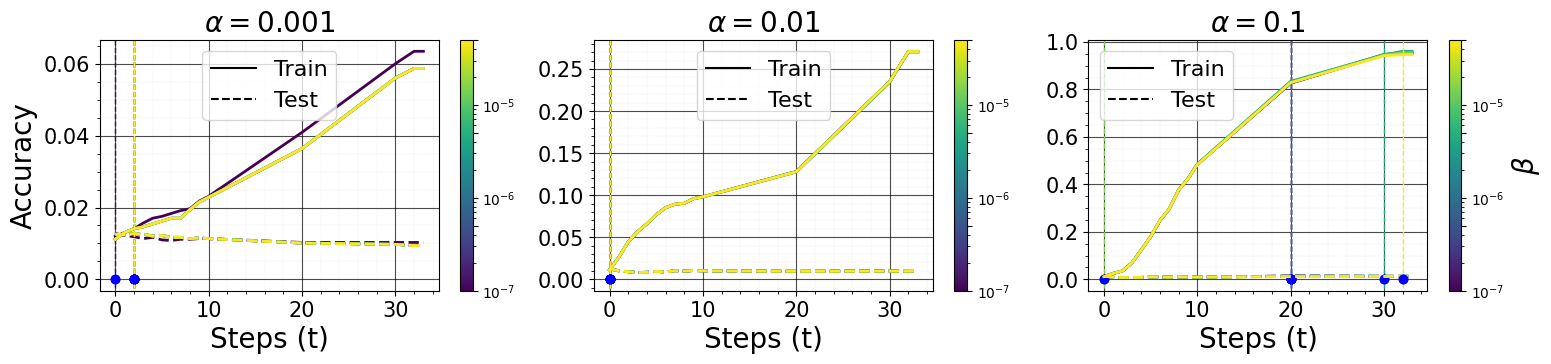

In [196]:
L=len(all_alpha)
cols = min(3, L)
rows = L // cols + 1 * (L % cols != 0)

figsize=FIGSIZE_SMALL
figsize=(cols*figsize[0], rows*figsize[1])
fig = plt.figure(figsize=figsize)

log_x=False
log_y=False

color_indices = np.linspace(0, 1, len(all_beta)+1*0)
colors = plt.cm.viridis(color_indices)

for i, alpha in enumerate(all_alpha):

    ax = fig.add_subplot(rows, cols, i+1)
    _, ax, _ = get_twin_axis(ax=ax, no_twin=True)
    #_, ax, ax1 = get_twin_axis(ax=ax, no_twin=False)

    ax.set_title(f'$\\alpha={alpha}$', fontsize=LABEL_FONTSIZE)

    for j, beta in enumerate(all_beta) :

        all_steps = all_statistics['all_steps'][alpha][beta]
        if log_x : all_steps = np.array(all_steps) + 1

        if to_plot == "loss" :
            test_errors, train_errors = all_statistics['test_loss'][alpha][beta], all_statistics['train_loss'][alpha][beta]
        elif to_plot == "error" :
            test_errors, train_errors = 1-np.array(all_statistics['test_accuracy'][alpha][beta]), 1-np.array(all_statistics['train_accuracy'][alpha][beta])
        elif to_plot == "accuracy" :
            test_errors, train_errors = all_statistics['test_accuracy'][alpha][beta], all_statistics['train_accuracy'][alpha][beta]

        ax.plot(all_steps, test_errors, '--', color=colors[j], linewidth=LINEWIDTH)
        ax.plot(all_steps, train_errors, '-', label=f'$\beta={beta}$', color=colors[j], linewidth=LINEWIDTH)

        # Plot times
        if to_plot == "loss" :
            test_errors, train_errors = all_statistics['test_loss'][alpha][beta], all_statistics['train_loss'][alpha][beta]
        elif to_plot == "error" or to_plot == "accuracy" :
            test_errors, train_errors = 1-np.array(all_statistics['test_accuracy'][alpha][beta]), 1-np.array(all_statistics['train_accuracy'][alpha][beta])
        # elif to_plot == "accuracy" :
        #     test_errors, train_errors = all_statistics['test_accuracy'][alpha][beta], all_statistics['train_accuracy'][alpha][beta]
        # t_2, t_2_index = find_stable_step_final_value(all_steps, test_errors, K=3, tolerance_fraction=0.05, M=2)
        t_1, t_2 = find_memorization_generalization_steps(train_errors, test_errors, all_steps, train_threshold=min(train_errors), test_threshold=min(test_errors))
        #plot_t1_t2(ax, t_1, t_2, log_x, log_y, plot_Delta=True)
        t = t_2
        if t is not None :
            ax.axvline(x=t, ymin=0.01, ymax=1., color=colors[j], linestyle='--', lw=1.)
            ax.plot([t, t], [0, 0], 'o', color='b')

    if (rows-1)*cols <= i < rows*cols : ax.set_xlabel('Steps (t)', fontsize=LABEL_FONTSIZE)
    if i%cols==0 : ax.set_ylabel(to_plot_label, fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis='both', labelsize=TICK_LABEL_FONTSIZE)

    ########### Color bar
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(all_beta), vmax=max(all_beta)))
    import matplotlib.colors as mcolors
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=mcolors.LogNorm(vmin=min(all_beta), vmax=max(all_beta)))
    sm.set_array([])  # We only need the colormap here, no actual data
    cbar = plt.colorbar(sm, ax=ax)
    if i==cols-1: cbar.set_label(f'$\\beta$', fontsize=LABEL_FONTSIZE)
    # # Set the ticks to correspond to the values in `all_beta_1`
    cbar.set_ticks(all_beta)  # Sets tick positions based on `all_beta`
    # cbar.set_ticklabels([str(beta) for beta in all_beta])  # Sets tick labels to match `all_beta`

    if log_x : ax.set_xscale('log')
    if log_y : ax.set_yscale('log')

    legend_elements = [
        Line2D([0], [0], color='k', linestyle='-', label='Train'),
        Line2D([0], [0], color='k', linestyle='--', label='Test')
        ]
    ax.legend(handles=legend_elements, fontsize=LABEL_FONTSIZE*0.8)


## Adjust layout and add padding
fig.tight_layout(pad=2)  # Adjust padding between plots
plt.subplots_adjust(right=0.85)  # Adjust right boundary of the plot to fit color bar

##
#plt.savefig(f"{LOG_DIR}/mlp_algorithmic_dataset_scaling_alpha_and_beta"  + '.pdf', dpi=300, bbox_inches='tight', format='pdf')

# plt.show()

**Figure xx** in *Grokking Beyond the Euclidean Norm of Model Parameters (Notsawo et al., 2025)*

<>:28: SyntaxWarning: invalid escape sequence '\ '
<>:80: SyntaxWarning: invalid escape sequence '\e'
<>:80: SyntaxWarning: invalid escape sequence '\e'
<>:86: SyntaxWarning: invalid escape sequence '\ '
<>:28: SyntaxWarning: invalid escape sequence '\ '
<>:80: SyntaxWarning: invalid escape sequence '\e'
<>:80: SyntaxWarning: invalid escape sequence '\e'
<>:86: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-1831849435.py:28: SyntaxWarning: invalid escape sequence '\ '
  ax.set_title(f'$\\alpha={alpha} \ ({to_plot_label})$', fontsize=LABEL_FONTSIZE)
/tmp/ipython-input-1831849435.py:80: SyntaxWarning: invalid escape sequence '\e'
  for norm_name, label in zip(['l2_norm', 'grad_norm'], ['\ell_2: \\ params', '\ell_2: \\ gradient']):
/tmp/ipython-input-1831849435.py:80: SyntaxWarning: invalid escape sequence '\e'
  for norm_name, label in zip(['l2_norm', 'grad_norm'], ['\ell_2: \\ params', '\ell_2: \\ gradient']):
/tmp/ipython-input-1831849435.py:86: SyntaxWarning: invalid e

<Figure size 1800x1200 with 0 Axes>

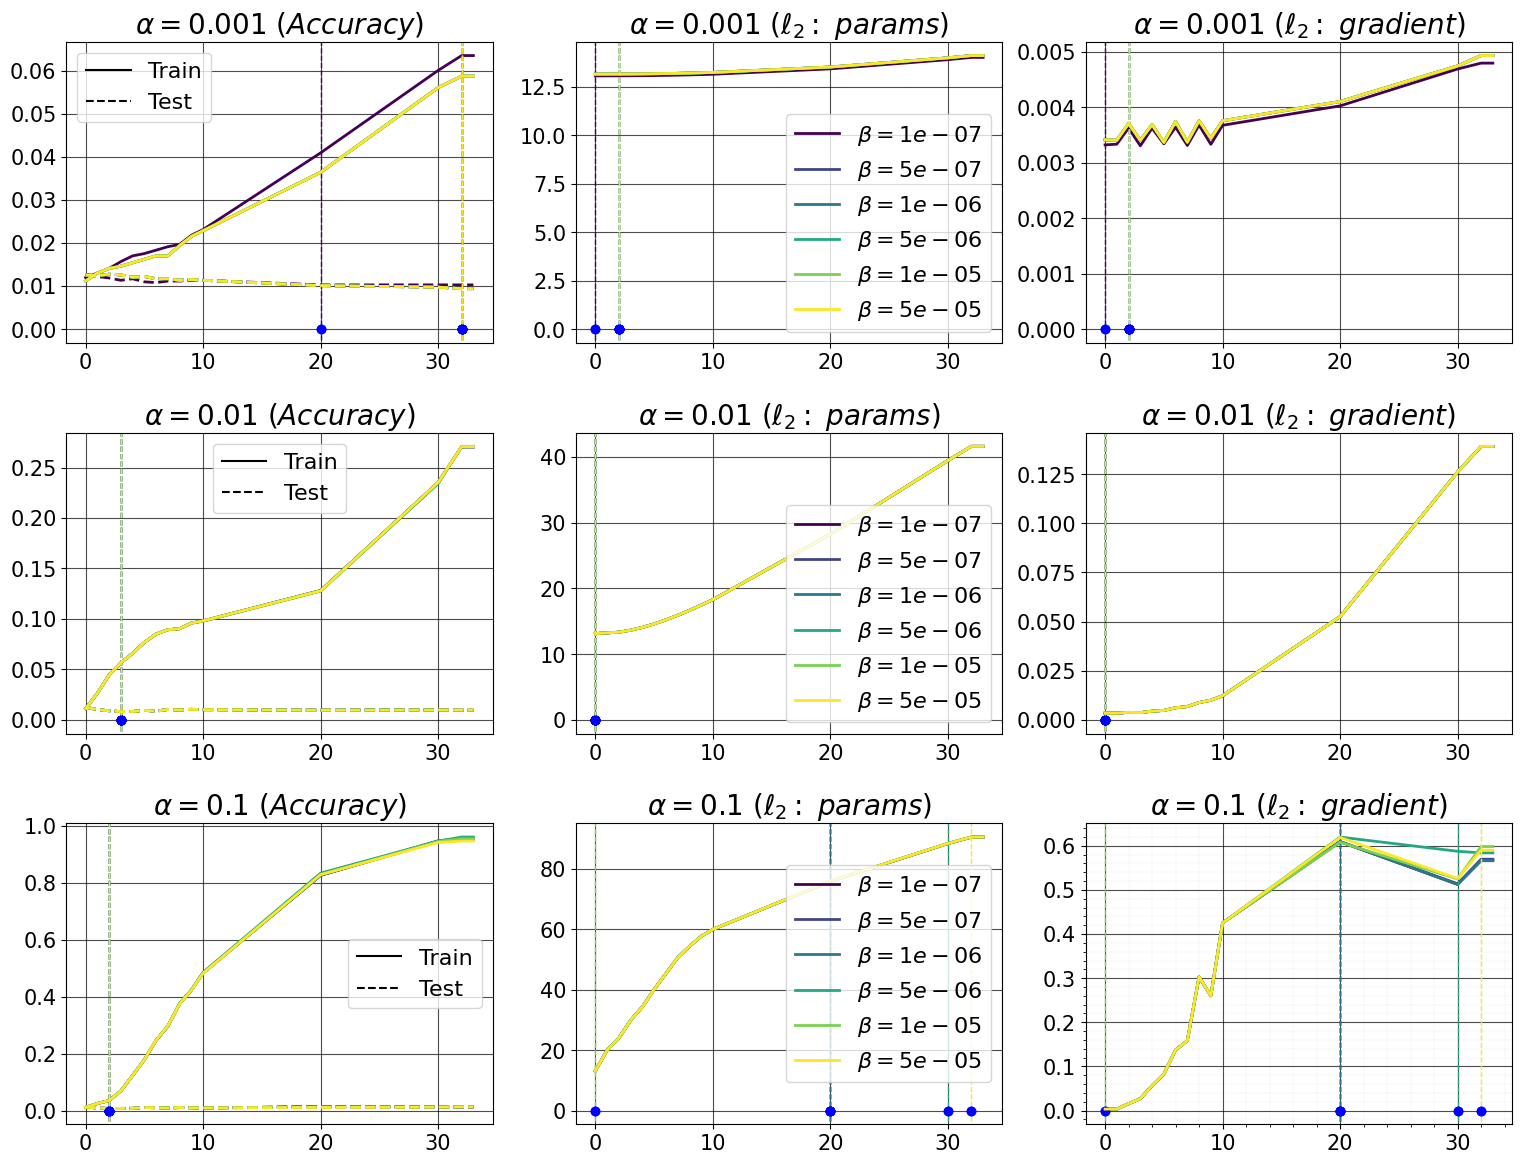

In [197]:
cols = 3
rows = len(all_alpha)

figsize=FIGSIZE_SMALL
figsize=(cols*figsize[0], rows*figsize[1])
fig = plt.figure(figsize=figsize)

fig, axes = plt.subplots(rows, cols, figsize=figsize)
if rows!=1 and cols!=1 :
    # flatten
    axes = [axes[i][j] for i in range(len(axes)) for j in range(len(axes[0]))]

log_x=False
log_y=False

color_indices = np.linspace(0, 1, len(all_beta)+1*0)
colors = plt.cm.viridis(color_indices)

k=0
for i, alpha in enumerate(all_alpha):

    #ax = fig.add_subplot(rows, cols, k+1)
    ax = axes[k]
    k+=1
    _, ax, _ = get_twin_axis(ax=ax, no_twin=True)
    #_, ax, ax1 = get_twin_axis(ax=ax, no_twin=False)

    ax.set_title(f'$\\alpha={alpha} \ ({to_plot_label})$', fontsize=LABEL_FONTSIZE)

    for j, beta in enumerate(all_beta) :

        all_steps = all_statistics['all_steps'][alpha][beta]
        if log_x : all_steps = np.array(all_steps) + 1

        if to_plot == "loss" :
            test_errors, train_errors = all_statistics['test_loss'][alpha][beta], all_statistics['train_loss'][alpha][beta]
        elif to_plot == "error" :
            test_errors, train_errors = 1-np.array(all_statistics['test_accuracy'][alpha][beta]), 1-np.array(all_statistics['train_accuracy'][alpha][beta])
        elif to_plot == "accuracy" :
            test_errors, train_errors = all_statistics['test_accuracy'][alpha][beta], all_statistics['train_accuracy'][alpha][beta]

        ax.plot(all_steps, test_errors, '--', color=colors[j], linewidth=LINEWIDTH)
        ax.plot(all_steps, train_errors, '-', label=f'$\\beta={beta}$', color=colors[j], linewidth=LINEWIDTH)

        # Plot times
        # t_2, t_2_index = find_stable_step_final_value(all_steps, test_errors, K=3, tolerance_fraction=0.05, M=2)
        t_1, t_2 = find_memorization_generalization_steps(train_errors, test_errors, all_steps, train_threshold=min(train_errors), test_threshold=min(test_errors))
        #plot_t1_t2(ax, t_1, t_2, log_x, log_y, plot_Delta=True)
        t = t_2
        if t is not None :
            ax.axvline(x=t, ymin=0.01, ymax=1., color=colors[j], linestyle='--', lw=1.)
            ax.plot([t, t], [0, 0], 'o', color='b')


    #if (rows-1)*cols <= i < rows*cols : ax.set_xlabel('Steps (t)', fontsize=LABEL_FONTSIZE)
    #if i%cols==0 : ax.set_ylabel(to_plot_label, fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis='both', labelsize=TICK_LABEL_FONTSIZE)

    ########### Color bar
    # sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(all_beta), vmax=max(all_beta)))
    # import matplotlib.colors as mcolors
    # sm = plt.cm.ScalarMappable(cmap='viridis', norm=mcolors.LogNorm(vmin=min(all_beta), vmax=max(all_beta)))
    # sm.set_array([])  # We only need the colormap here, no actual data
    # cbar = plt.colorbar(sm, ax=ax, location='left', pad=0.2, fraction=0.1, shrink=0.9)
    # plt.tight_layout()  # Automatically adjusts layout
    # cbar.set_label(f'$\\beta$', fontsize=LABEL_FONTSIZE)
    # # # Set the ticks to correspond to the values in `all_beta_1`
    # cbar.set_ticks(all_beta)  # Sets tick positions based on `all_beta`
    # # cbar.set_ticklabels([str(beta) for beta in all_beta])  # Sets tick labels to match `all_beta`

    if log_x : ax.set_xscale('log')
    if log_y : ax.set_yscale('log')

    legend_elements = [
        Line2D([0], [0], color='k', linestyle='-', label='Train'),
        Line2D([0], [0], color='k', linestyle='--', label='Test')
        ]
    ax.legend(handles=legend_elements, fontsize=LABEL_FONTSIZE*0.8)

    for norm_name, label in zip(['l2_norm', 'grad_norm'], ['\ell_2: \\ params', '\ell_2: \\ gradient']):
        #ax = fig.add_subplot(rows, cols, k+1)
        ax = axes[k]
        k+=1
        _, ax, _ = get_twin_axis(ax=ax, no_twin=True)

        ax.set_title(f'$\\alpha={alpha} \ ({label})$', fontsize=LABEL_FONTSIZE)

        for j, beta in enumerate(all_beta) :

            all_steps = all_statistics['all_steps'][alpha][beta]
            if log_x : all_steps = np.array(all_steps) + 1

            ax.plot(all_steps, all_statistics[norm_name][alpha][beta], "-", color=colors[j], label=f'$\\beta={beta}$', linewidth=LINEWIDTH)

             # Plot times
            if to_plot == "loss" :
                test_errors, train_errors = all_statistics['test_loss'][alpha][beta], all_statistics['train_loss'][alpha][beta]
            elif to_plot == "error" or to_plot=="accuracy" :
                test_errors, train_errors = 1-np.array(all_statistics['test_accuracy'][alpha][beta]), 1-np.array(all_statistics['train_accuracy'][alpha][beta])
            # elif to_plot == "accuracy" :
            #     test_errors, train_errors = all_statistics['test_accuracy'][alpha][beta], all_statistics['train_accuracy'][alpha][beta]

            # t_2, t_2_index = find_stable_step_final_value(all_steps, test_errors, K=3, tolerance_fraction=0.05, M=2)
            t_1, t_2 = find_memorization_generalization_steps(train_errors, test_errors, all_steps, train_threshold=min(test_errors), test_threshold=min(test_errors))
            #plot_t1_t2(ax, t_1, t_2, log_x, log_y, plot_Delta=True)
            t = t_2
            if t is not None :
                ax.axvline(x=t, ymin=0.01, ymax=1., color=colors[j], linestyle='--', lw=1.)
                ax.plot([t, t], [0, 0], 'o', color='b')

        # if (rows-1)*cols <= i < rows*cols : ax.set_xlabel('Steps (t)', fontsize=LABEL_FONTSIZE)
        # if i%cols==0 : ax.set_ylabel(f'$l_2$', fontsize=LABEL_FONTSIZE)
        ax.tick_params(axis='both', labelsize=TICK_LABEL_FONTSIZE)

        if log_x : ax.set_xscale('log')
        if log_y : ax.set_yscale('log')

        if (k-2)%cols==0:
            ax.legend(fontsize=LABEL_FONTSIZE*0.8)

# # Create the ScalarMappable for the color bar
# sm = plt.cm.ScalarMappable(cmap='viridis', norm=mcolors.LogNorm(vmin=min(all_beta), vmax=max(all_beta)))
# sm.set_array([])
# # Add a single horizontal color bar on top of the figure
# cbar = fig.colorbar(sm, ax=axes, location='top', orientation='horizontal', pad=0.1, aspect=50, fraction=0.01, shrink=0.7)
# cbar.set_label('$\\beta$', fontsize=LABEL_FONTSIZE)
# cbar.set_ticks(all_beta)

## Adjust layout and add padding
fig.tight_layout(pad=2)  # Adjust padding between plots
plt.subplots_adjust(right=0.85)  # Adjust right boundary of the plot to fit color bar

##
#plt.savefig(f"{LOG_DIR}/mlp_algorithmic_dataset_scaling_alpha_and_beta_with_norms"  + '.pdf', dpi=300, bbox_inches='tight', format='pdf')

#plt.show()

**Figure 1** in *Grokking Beyond the Euclidean Norm of Model Parameters (Notsawo et al., 2025)*

In [198]:
all_T_max_dic = [None, None, None]
#all_T_max_dic = [None, 500, 310]
kappa=1.5

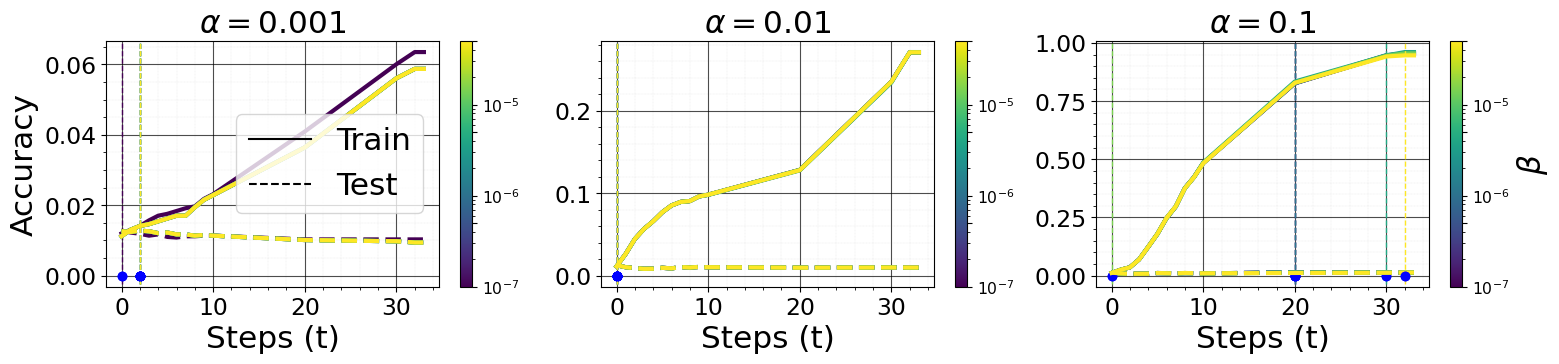

In [199]:
L=len(all_alpha)
cols = min(3, L)
rows = L // cols + 1 * (L % cols != 0)

figsize=FIGSIZE_SMALL
figsize=(cols*figsize[0], rows*figsize[1])
fig = plt.figure(figsize=figsize)

log_x=False
log_y=False

color_indices = np.linspace(0, 1, len(all_beta)+1*0)
colors = plt.cm.viridis(color_indices)

for i, alpha in enumerate(all_alpha):

    ax = fig.add_subplot(rows, cols, i+1)
    _, ax, _ = get_twin_axis(ax=ax, no_twin=True)
    #_, ax, ax1 = get_twin_axis(ax=ax, no_twin=False)

    ax.set_title(f'$\\alpha={alpha}$', fontsize=LABEL_FONTSIZE*(3*kappa/4))

    for j, beta in enumerate(all_beta) :

        all_steps = all_statistics['all_steps'][alpha][beta]
        if log_x : all_steps = np.array(all_steps) + 1

        if to_plot == "loss" :
            test_errors, train_errors = all_statistics['test_loss'][alpha][beta], all_statistics['train_loss'][alpha][beta]
        elif to_plot == "error" :
            test_errors, train_errors = 1-np.array(all_statistics['test_accuracy'][alpha][beta]), 1-np.array(all_statistics['train_accuracy'][alpha][beta])
        elif to_plot == "accuracy" :
            test_errors, train_errors = all_statistics['test_accuracy'][alpha][beta], all_statistics['train_accuracy'][alpha][beta]

        T_max = all_T_max_dic[i]
        all_steps, test_errors, train_errors = all_steps[:T_max], test_errors[:T_max], train_errors[:T_max]

        ax.plot(all_steps, test_errors, '--', color=colors[j], linewidth=LINEWIDTH*kappa)
        ax.plot(all_steps, train_errors, '-', label=f'$\\beta={beta}$', color=colors[j], linewidth=LINEWIDTH*kappa)


        # Plot times
        if to_plot == "loss" :
            test_errors, train_errors = all_statistics['test_loss'][alpha][beta], all_statistics['train_loss'][alpha][beta]
        elif to_plot == "error" or to_plot == "accuracy" :
            test_errors, train_errors = 1-np.array(all_statistics['test_accuracy'][alpha][beta]), 1-np.array(all_statistics['train_accuracy'][alpha][beta])
        all_steps, test_errors, train_errors = all_steps[:T_max], test_errors[:T_max], train_errors[:T_max]
        # t_2, t_2_index = find_stable_step_final_value(all_steps, test_errors, K=3, tolerance_fraction=0.05, M=2)
        t_1, t_2 = find_memorization_generalization_steps(train_errors, test_errors, all_steps, train_threshold=min(train_errors), test_threshold=min(test_errors))
        #plot_t1_t2(ax, t_1, t_2, log_x, log_y, plot_Delta=True)
        t = t_2
        if t is not None :
            ax.axvline(x=t, ymin=0.01, ymax=1., color=colors[j], linestyle='--', lw=1.)
            ax.plot([t, t], [0, 0], 'o', color='b')

    if (rows-1)*cols <= i < rows*cols : ax.set_xlabel('Steps (t)', fontsize=LABEL_FONTSIZE*(3*kappa/4))
    if i%cols==0 : ax.set_ylabel(to_plot_label, fontsize=LABEL_FONTSIZE*(3*kappa/4))
    ax.tick_params(axis='both', labelsize=TICK_LABEL_FONTSIZE*(3*kappa/4))

    ########### Color bar
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(all_beta), vmax=max(all_beta)))
    import matplotlib.colors as mcolors
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=mcolors.LogNorm(vmin=min(all_beta), vmax=max(all_beta)))
    sm.set_array([])  # We only need the colormap here, no actual data
    cbar = plt.colorbar(sm, ax=ax)
    if i==cols-1: cbar.set_label(f'$\\beta$', fontsize=LABEL_FONTSIZE*(3*kappa/4))
    # # Set the ticks to correspond to the values in `all_beta_1`
    cbar.set_ticks(all_beta)  # Sets tick positions based on `all_beta`
    # cbar.set_ticklabels([str(beta) for beta in all_beta])  # Sets tick labels to match `all_beta`
    cbar.ax.tick_params(labelsize=TICK_LABEL_FONTSIZE*(kappa/2))  #

    if log_x : ax.set_xscale('log')
    if log_y : ax.set_yscale('log')

    legend_elements = [
        Line2D([0], [0], color='k', linestyle='-', label='Train'),
        Line2D([0], [0], color='k', linestyle='--', label='Test')
        ]
    if i==0 :ax.legend(handles=legend_elements, fontsize=LABEL_FONTSIZE*(3*kappa/4))


## Adjust layout and add padding
fig.tight_layout(pad=2)  # Adjust padding between plots
plt.subplots_adjust(right=0.85)  # Adjust right boundary of the plot to fit color bar

##
#plt.savefig(f"{LOG_DIR}/mlp_algorithmic_dataset_scaling_alpha_and_beta_small_plot"  + '.pdf', dpi=300, bbox_inches='tight', format='pdf')

# plt.show()